<a href="https://colab.research.google.com/github/adityab-tech/Prism/blob/main/W1_Prism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Libraries and Save to Drive Codes

In [1]:
!pip install yfinance pandas matplotlib numpy tqdm


In [2]:
!pip install -q yfinance

In [3]:
import yfinance as yf

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

from tqdm import tqdm

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

base_path = "/content/drive/MyDrive/PRISM"

folders = [
    "raw_data",
    "processed_data",
    "notebooks",
    "models",
    "outputs"
]

for folder in folders:
    os.makedirs(os.path.join(base_path, folder), exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [6]:
import os

print(os.listdir("/content/drive/MyDrive/PRISM"))

['processed_data', 'notebooks', 'models', 'outputs', 'raw_data', 'processed']


#TCS Stock example

In [7]:
stock = yf.download(
    "TCS.NS",
    start="2019-01-01",
    end="2025-01-01",
    auto_adjust=False,
    progress=False
)

stock.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS,TCS.NS
Date,,,,,,
2019-01-01,1561.000366,1902.800049,1910.000000,1885.000000,1896.000000,1094883
2019-01-02,1577.818115,1923.300049,1934.449951,1900.000000,1905.000000,2100463
2019-01-03,1558.662354,1899.949951,1944.949951,1893.099976,1919.000000,2611668
2019-01-04,1539.711792,1876.849976,1901.199951,1841.000000,1900.000000,4280862
2019-01-07,1556.980713,1897.900024,1908.800049,1881.000000,1891.800049,1856423


In [8]:
if isinstance(stock.columns, pd.MultiIndex):
    stock.columns = stock.columns.get_level_values(0)

In [9]:
stock.describe()

Price,Adj Close,Close,High,Low,Open,Volume
count,1481.000000,1481.000000,1481.000000,1481.000000,1481.000000,1.481000e+03
mean,2751.234888,3099.413369,3130.185580,3069.546090,3100.470729,2.745963e+06
std,735.664116,735.400016,738.971315,731.893383,734.961891,1.660880e+06
min,1403.242676,1636.349976,1685.449951,1506.050049,1559.699951,1.548950e+05
25%,1901.627075,2250.850098,2268.750000,2230.100098,2250.600098,1.711510e+06
50%,2889.345947,3251.050049,3275.000000,3222.050049,3250.000000,2.316539e+06
75%,3231.117676,3623.800049,3650.000000,3591.699951,3620.000000,3.224657e+06
max,4253.906738,4553.750000,4592.250000,4512.000000,4576.000000,1.983933e+07


In [10]:
stock = stock.reset_index()
stock = stock[[
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Volume"
]]

In [11]:
stock.head()

Price,Date,Open,High,Low,Close,Volume
0,2019-01-01,1896.000000,1910.000000,1885.000000,1902.800049,1094883
1,2019-01-02,1905.000000,1934.449951,1900.000000,1923.300049,2100463
2,2019-01-03,1919.000000,1944.949951,1893.099976,1899.949951,2611668
3,2019-01-04,1900.000000,1901.199951,1841.000000,1876.849976,4280862
4,2019-01-07,1891.800049,1908.800049,1881.000000,1897.900024,1856423


In [12]:
stock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1481 entries, 0 to 1480
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1481 non-null   datetime64[ns]
 1   Open    1481 non-null   float64       
 2   High    1481 non-null   float64       
 3   Low     1481 non-null   float64       
 4   Close   1481 non-null   float64       
 5   Volume  1481 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 69.6 KB


In [13]:
stock.shape

(1481, 6)

In [14]:
stock.head()

Price,Date,Open,High,Low,Close,Volume
0,2019-01-01,1896.000000,1910.000000,1885.000000,1902.800049,1094883
1,2019-01-02,1905.000000,1934.449951,1900.000000,1923.300049,2100463
2,2019-01-03,1919.000000,1944.949951,1893.099976,1899.949951,2611668
3,2019-01-04,1900.000000,1901.199951,1841.000000,1876.849976,4280862
4,2019-01-07,1891.800049,1908.800049,1881.000000,1897.900024,1856423


In [15]:
stock.isnull().sum()

,0
Price,
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0


In [16]:
stock.duplicated().sum()

np.int64(0)

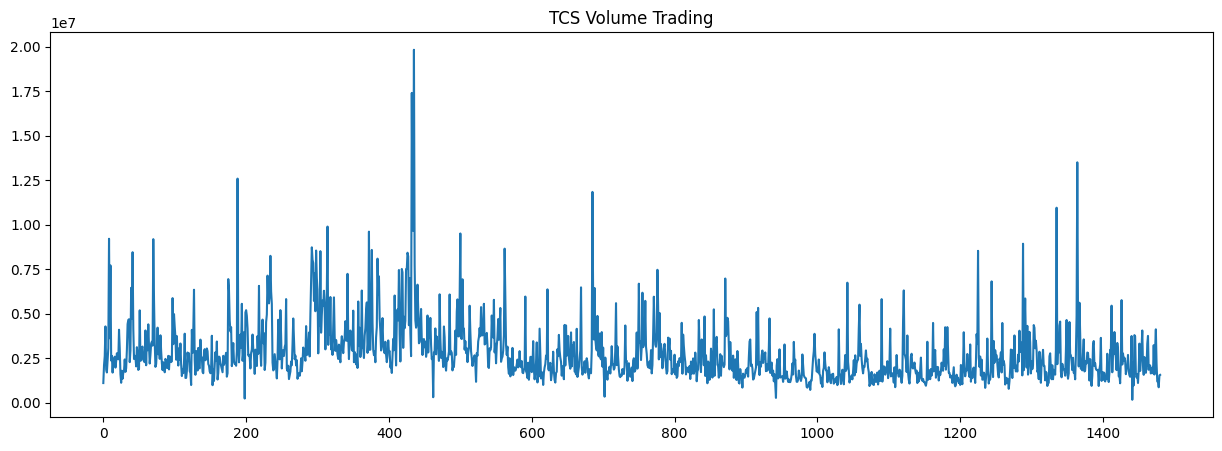

In [17]:
plt.figure(figsize=(15,5))

plt.plot(stock["Volume"])

plt.title("TCS Volume Trading")

plt.show()

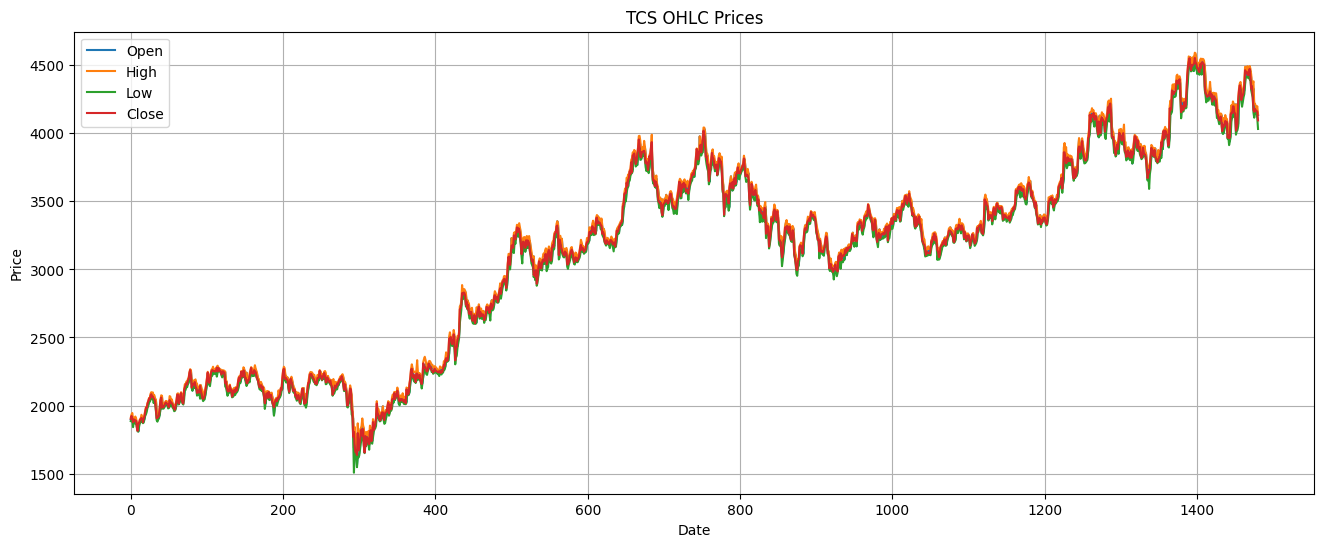

In [18]:
plt.figure(figsize=(16,6))

plt.plot(stock["Open"], label="Open")
plt.plot(stock["High"], label="High")
plt.plot(stock["Low"], label="Low")
plt.plot(stock["Close"], label="Close")

plt.title("TCS OHLC Prices")
plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(True)
plt.show()

In [19]:
stock.to_csv(
"/content/drive/MyDrive/PRISM/raw_data/TCS.csv"
)

#NSEI Data Example

In [20]:
nifty = yf.download(
    "^NSEI",
    start="2019-01-01",
    end="2025-01-01"
)

/tmp/ipykernel_6385/1178418048.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  nifty = yf.download(
[*********************100%***********************]  1 of 1 completed


In [21]:
nifty.head()

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
Date,,,,,
2019-01-02,10792.500000,10895.349609,10735.049805,10868.849609,309700
2019-01-03,10672.250000,10814.049805,10661.250000,10796.799805,286200
2019-01-04,10727.349609,10741.049805,10628.650391,10699.700195,296600
2019-01-07,10771.799805,10835.950195,10750.150391,10804.849609,269400
2019-01-08,10802.150391,10818.450195,10733.250000,10786.250000,277700


In [22]:
nifty.describe()

Price,Close,High,Low,Open,Volume
Ticker,^NSEI,^NSEI,^NSEI,^NSEI,^NSEI
count,1478.000000,1478.000000,1478.000000,1478.000000,1.478000e+03
mean,16377.479877,16466.592692,16283.075226,16388.508256,4.023426e+05
std,4414.004554,4421.859628,4405.253876,4413.605901,2.078055e+05
min,7610.250000,8036.950195,7511.100098,7735.149902,0.000000e+00
25%,11914.250244,11970.350098,11851.175049,11928.824951,2.573250e+05
50%,16954.699219,17091.625000,16830.774414,16962.400391,3.336000e+05
75%,18943.387207,19034.086914,18855.474609,18923.600098,5.147000e+05
max,26216.050781,26277.349609,26151.400391,26248.250000,1.811000e+06


In [23]:
nifty.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1478 entries, 2019-01-02 to 2024-12-31
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, ^NSEI)   1478 non-null   float64
 1   (High, ^NSEI)    1478 non-null   float64
 2   (Low, ^NSEI)     1478 non-null   float64
 3   (Open, ^NSEI)    1478 non-null   float64
 4   (Volume, ^NSEI)  1478 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 69.3 KB


In [24]:
nifty.shape

(1478, 5)

In [25]:
nifty.isnull().sum()

,,0
Price,Ticker,
Close,^NSEI,0
High,^NSEI,0
Low,^NSEI,0
Open,^NSEI,0
Volume,^NSEI,0


In [26]:
nifty.duplicated().sum()

np.int64(0)

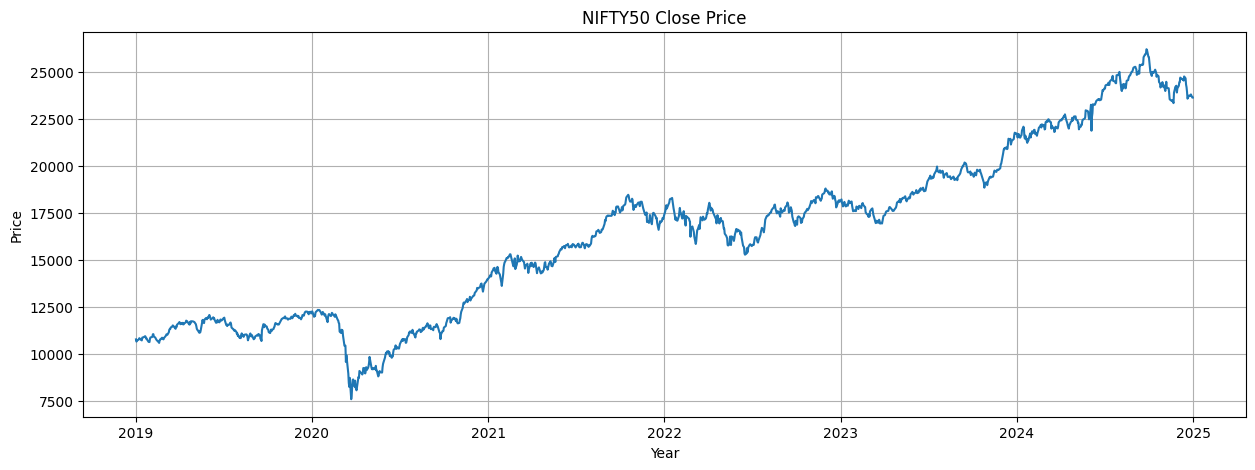

In [27]:
plt.figure(figsize=(15,5))

plt.plot(nifty["Close"])

plt.title("NIFTY50 Close Price")
plt.xlabel("Year")
plt.ylabel("Price")

plt.grid(True) #add grids
plt.show()

In [28]:
nifty.to_csv(
"/content/drive/MyDrive/PRISM/raw_data/NIFTY50.csv"
)

#Downloading Stocks

In [29]:
stocks = [
    "3MINDIA.NS",       # 3M India Ltd.
    "AARTIDRUGS.NS",    # Aarti Drugs Ltd.
    "AAVAS.NS",         # Aavas Financiers Ltd.
    "ABB.NS",           # ABB India Ltd.
    "ABBOTINDIA.NS",    # Abbott India Ltd.
    "ABCAPITAL.NS",     # Aditya Birla Capital Ltd.
    "ABFRL.NS",         # Aditya Birla Fashion and Retail Ltd.
    "ABSLAMC.NS",       # Aditya Birla Sun Life AMC Ltd.
    "ACC.NS",           # ACC Ltd.
    "ADANIENT.NS",      # Adani Enterprises Ltd.
    "ADANIGREEN.NS",    # Adani Green Energy Ltd.
    "ADANIPORTS.NS",    # Adani Ports and Special Economic Zone Ltd.
    "ADANITRANS.NS",    # Adani Transmission Ltd.
    "ADVENZYMES.NS",    # Advanced Enzyme Tech Ltd.
    "AEGISCHEM.NS",     # Aegis Logistics Ltd.
    "AFFLE.NS",         # Affle (India) Ltd.
    "AIAENG.NS",        # AIA Engineering Ltd.
    "AJANTPHARM.NS",    # Ajanta Pharmaceuticals Ltd.
    "ALKEM.NS",         # Alkem Laboratories Ltd.
    "ALKYLAMINE.NS",    # Alkyl Amines Chemicals Ltd.
    "ALLCARGO.NS",      # Allcargo Logistics Ltd.
    "ALOKINDS.NS",      # Alok Industries Ltd.
    "AMARAJABAT.NS",    # Amara Raja Batteries Ltd.
    "AMBER.NS",         # Amber Enterprises India Ltd.
    "AMBUJACEM.NS",     # Ambuja Cements Ltd.
    "ANGELONE.NS",      # Angel One Ltd.
    "ANURAS.NS",        # Anupam Rasayan India Ltd.
    "APLAPOLLO.NS",     # APL Apollo Tubes Ltd.
    "ALEMBICPHARM.NS",  # Alembic Pharmaceuticals Ltd.
    "APOLLOHOSP.NS",    # Apollo Hospitals Enterprise Ltd.
    "APOLLOTYRE.NS",    # Apollo Tyres Ltd.
    "APTUS.NS",         # Aptus Value Housing Finance India Ltd.
    "ASAHIINDIA.NS",    # Asahi India Glass Ltd.
    "ASHOKLEY.NS",      # Ashok Leyland Ltd.
    "ASIANPAINT.NS",    # Asian Paints Ltd.
    "ASTERDM.NS",       # Aster DM Healthcare Ltd.
    "ASTRAL.NS",        # Astral Ltd.
    "ASTRAZEN.NS",      # AstraZeneca Pharma India Ltd.
    "ATGL.NS",          # Adani Total Gas Ltd.
    "ATUL.NS",          # Atul Ltd.
    "AUBANK.NS",        # AU Small Finance Bank Ltd.
    "AUROPHARMA.NS",    # Aurobindo Pharma Ltd.
    "AVANTIFEED.NS",    # Avanti Feeds Ltd.
    "AXISBANK.NS",      # Axis Bank Ltd.
    "BAJAJ-AUTO.NS",    # Bajaj Auto Ltd.
    "BAJAJELEC.NS",     # Bajaj Electricals Ltd
    "BAJAJFINSV.NS",    # Bajaj Finserv Ltd.
    "BAJAJHLDNG.NS",    # Bajaj Holdings & Investment Ltd.
    "BAJFINANCE.NS",    # Bajaj Finance Ltd.
    "BALAMINES.NS",     # Balaji Amines Ltd.
    "BALKRISIND.NS",    # Balkrishna Industries Ltd.
    "BALRAMCHIN.NS",    # Balrampur Chini Mills Ltd.
    "BANDHANBNK.NS",    # Bandhan Bank Ltd.
    "BANKBARODA.NS",    # Bank of Baroda
    "BANKINDIA.NS",     # Bank of India
    "BASF.NS",          # BASF India Ltd.
    "BATAINDIA.NS",     # Bata India Ltd.
    "BAYERCROP.NS",     # Bayer Cropscience Ltd.
    "BBTC.NS",          # Bombay Burmah Trading Corporation Ltd.
    "BCG.NS",           # Brightcom Group Ltd.
    "BDL.NS",           # Bharat Dynamics Ltd.
    "BEL.NS",           # Bharat Electronics Ltd.
    "BERGEPAINT.NS",    # Berger Paints India Ltd.
    "BHARATFORG.NS",    # Bharat Forge Ltd.
    "BHARTIARTL.NS",    # Bharti Airtel Ltd.
    "BHEL.NS",          # Bharat Heavy Electricals Ltd.
    "BIOCON.NS",        # Biocon Ltd.
    "BIRLACORPN.NS",    # Birla Corporation Ltd.
    "BLUEDART.NS",      # Blue Dart Express Ltd.
    "BLUESTARCO.NS",    # Blue Star Ltd.
    "BORORENEW.NS",     # Borosil Renewables Ltd.
    "BOSCHLTD.NS",      # Bosch Ltd.
    "BPCL.NS",          # Bharat Petroleum Corporation Ltd.
    "BRIGADE.NS",       # Brigade Enterprises Ltd.
    "BRITANNIA.NS",     # Britannia Industries Ltd.
    "BSE.NS",           # BSE Ltd.
    "BSOFT.NS",         # Birlasoft Ltd.
    "CAMS.NS",          # Computer Age Management Services Ltd.
    "CANBK.NS",         # Canara Bank
    "CANFINHOME.NS",    # Can Fin Homes Ltd.
    "CAPLIPOINT.NS",    # Caplin Point Laboratories Ltd.
    "CARBORUNIV.NS",    # Carborundum Universal Ltd.
    "CASTROLIND.NS",    # Castrol India Ltd.
    "CCL.NS",           # CCL Products (I) Ltd.
    "CDSL.NS",          # Central Depository Services (India) Ltd.
    "CEATLTD.NS",       # Ceat Ltd.
    "CENTRALBK.NS",     # Central Bank of India
    "CENTURYPLY.NS",    # Century Plyboards (India) Ltd.
    "CENTURYTEX.NS",    # Century Textile & Industries Ltd.
    "CERA.NS",          # Cera Sanitaryware Ltd
    "CESC.NS",          # CESC Ltd.
    "CGCL.NS",          # Capri Global Capital Ltd.
    "CGPOWER.NS",       # CG Power and Industrial Solutions Ltd.
    "CHALET.NS",        # Chalet Hotels Ltd.
    "CHAMBLFERT.NS",    # Chambal Fertilizers & Chemicals Ltd.
    "CHEMPLASTS.NS",    # Chemplast Sanmar Ltd.
    "CHOLAFIN.NS",      # Cholamandalam Investment and Finance Company Ltd.
    "CHOLAHLDNG.NS",    # Cholamandalam Financial Holdings Ltd.
    "CIPLA.NS",         # Cipla Ltd.
    "CLEAN.NS",         # Clean Science and Technology Ltd.
    "COALINDIA.NS",     # Coal India Ltd.
    "COCHINSHIP.NS",    # Cochin Shipyard Ltd.
    "COFORGE.NS",       # Coforge Ltd.
    "COLPAL.NS",        # Colgate Palmolive (India) Ltd.
    "CONCOR.NS",        # Container Corporation of India Ltd.
    "COROMANDEL.NS",    # Coromandel International Ltd.
    "CREDITACC.NS",     # CreditAccess Grameen Ltd.
    "CRISIL.NS",        # CRISIL Ltd.
    "CROMPTON.NS",      # Crompton Greaves Consumer Electricals Ltd.
    "CSBBANK.NS",       # CSB Bank Ltd.
    "CUB.NS",           # City Union Bank Ltd.
    "CUMMINSIND.NS",    # Cummins India Ltd.
    "CYIENT.NS",        # Cyient Ltd.
    "DABUR.NS",         # Dabur India Ltd.
    "DALBHARAT.NS",     # Dalmia Bharat Ltd.
    "DBL.NS",           # Dilip Buildcon Ltd.
    "DCMSHRIRAM.NS",    # DCM Shriram Ltd.
    "DEEPAKNTR.NS",     # Deepak Nitrite Ltd.
    "DELTACORP.NS",     # Delta Corp Ltd.
    "DEVYANI.NS",       # Devyani International Ltd.
    "DHANI.NS",         # Dhani Services Ltd.
    "DIVISLAB.NS",      # Divi's Laboratories Ltd.
    "DIXON.NS",         # Dixon Technologies (India) Ltd.
    "DLF.NS",           # DLF Ltd.
    "DMART.NS",         # Avenue Supermarts Ltd.
    "DRREDDY.NS",       # Dr. Reddy's Laboratories Ltd.
    "EASEMYTRIP.NS",    # Easy Trip Planners Ltd.
    "ECLERX.NS",        # eClerx Services Ltd.
    "EDELWEISS.NS",     # Edelweiss Financial Services Ltd.
    "EICHERMOT.NS",     # Eicher Motors Ltd.
    "EIDPARRY.NS",      # E.I.D. Parry (India) Ltd.
    "EIHOTEL.NS",       # EIH Ltd.
    "ELGIEQUIP.NS",     # Elgi Equipments Ltd.
    "EMAMILTD.NS",      # Emami Ltd.
    "ENDURANCE.NS",     # Endurance Technologies Ltd.
    "ENGINERSIN.NS",    # Engineers India Ltd.
    "EPL.NS",           # EPL Ltd.
    "EQUITASBNK.NS",    # Equitas Small Finance Bank Ltd.
    "ERIS.NS",          # Eris Lifesciences Ltd.
    "ESCORTS.NS",       # Escorts Kubota Ltd.
    "EXIDEIND.NS",      # Exide Industries Ltd.
    "FACT.NS",          # Fertilisers and Chemicals Travancore Ltd.
    "FDC.NS",           # FDC Ltd.
    "FEDERALBNK.NS",    # Federal Bank Ltd.
    "FINCABLES.NS",     # Finolex Cables Ltd.
    "FINEORG.NS",       # Fine Organic Industries Ltd.
    "FINPIPE.NS",       # Finolex Industries Ltd.
    "FLUOROCHEM.NS",    # Gujarat Fluorochemicals Ltd.
    "FORTIS.NS",        # Fortis Healthcare Ltd.
    "FSL.NS",           # Firstsource Solutions Ltd.
    "GAEL.NS",          # Gujarat Ambuja Exports Ltd.
    "GAIL.NS",          # GAIL (India) Ltd.
    "GALAXYSURF.NS",    # Galaxy Surfactants Ltd.
    "GARFIBRES.NS",     # Garware Technical Fibres Ltd.
    "GESHIP.NS",        # Great Eastern Shipping Co. Ltd.
    "GICRE.NS",         # General Insurance Corporation of India
    "GLAND.NS",         # Gland Pharma Ltd.
    "GLAXO.NS",         # Glaxosmithkline Pharmaceuticals Ltd.
    "GLENMARK.NS",      # Glenmark Pharmaceuticals Ltd.
    "GLS.NS",           # Glenmark Life Sciences Ltd.
    "GMMPFAUDLR.NS",    # GMM Pfaudler Ltd.
    "GMRINFRA.NS",      # GMR Infrastructure Ltd.
    "GNFC.NS",          # Gujarat Narmada Valley Fertilizers and Chemicals Ltd.
    "GOCOLORS.NS",      # Go Fashion (India) Ltd.
    "GODFRYPHLP.NS",    # Godfrey Phillips India Ltd.
    "GODREJAGRO.NS",    # Godrej Agrovet Ltd.
    "GODREJCP.NS",      # Godrej Consumer Products Ltd.
    "GODREJIND.NS",     # Godrej Industries Ltd.
    "GODREJPROP.NS",    # Godrej Properties Ltd.
    "GPPL.NS",          # Gujarat Pipavav Port Ltd.
    "GRANULES.NS",      # Granules India Ltd.
    "GRAPHITE.NS",      # Graphite India Ltd.
    "GRASIM.NS",        # Grasim Industries Ltd.
    "GRINDWELL.NS",     # Grindwell Norton Ltd.
    "GRINFRA.NS",       # G R Infraprojects Ltd.
    "GSFC.NS",          # Gujarat State Fertilizers & Chemicals Ltd.
    "GSPL.NS",          # Gujarat State Petronet Ltd.
    "GUJALKALI.NS",     # Gujarat Alkalies & Chemicals Ltd.
    "GUJGASLTD.NS",     # Gujarat Gas Ltd.
    "HAL.NS",           # Hindustan Aeronautics Ltd.
    "HAPPSTMNDS.NS",    # Happiest Minds Technologies Ltd.
    "HATHWAY.NS",       # Hathway Cable & Datacom Ltd.
    "HATSUN.NS",        # Hatsun Agro Product Ltd.
    "HAVELLS.NS",       # Havells India Ltd.
    "HCLTECH.NS",       # HCL Technologies Ltd.
    "HDFC.NS",          # Housing Development Finance Corporation Ltd.
    "HDFCAMC.NS",       # HDFC Asset Management Company Ltd.
    "HDFCBANK.NS",      # HDFC Bank Ltd.
    "HDFCLIFE.NS",      # HDFC Life Insurance Company Ltd.
    "HEG.NS",           # H.E.G. Ltd.
    "HEMIPROP.NS",      # Hemisphere Properties India Ltd.
    "HEROMOTOCO.NS",    # Hero MotoCorp Ltd.
    "HFCL.NS",          # HFCL Ltd.
    "HGS.NS",           # Hinduja Global Solutions Ltd.
    "HIKAL.NS",         # Hikal Ltd.
    "HINDALCO.NS",      # Hindalco Industries Ltd.
    "HINDCOPPER.NS",    # Hindustan Copper Ltd.
    "HINDPETRO.NS",     # Hindustan Petroleum Corporation Ltd.
    "HINDUNILVR.NS",    # Hindustan Unilever Ltd.
    "HINDZINC.NS",      # Hindustan Zinc Ltd.
    "HLEGLAS.NS",       # HLE Glascoat Ltd.
    "HOMEFIRST.NS",     # Home First Finance Company India Ltd.
    "HONAUT.NS",        # Honeywell Automation India Ltd.
    "HUDCO.NS",         # Housing & Urban Development Corporation Ltd.
    "IBREALEST.NS",     # Indiabulls Real Estate Ltd.
    "IBULHSGFIN.NS",    # Indiabulls Housing Finance Ltd.
    "ICICIBANK.NS",     # ICICI Bank Ltd.
    "ICICIGI.NS",       # ICICI Lombard General Insurance Company Ltd.
    "ICICIPRULI.NS",    # ICICI Prudential Life Insurance Company Ltd.
    "ICIL.NS",          # Indo Count Industries Ltd.
    "IDBI.NS",          # IDBI Bank Ltd.
    "IDEA.NS",          # Vodafone Idea Ltd.
    "IDFC.NS",          # IDFC Ltd.
    "IDFCFIRSTB.NS",    # IDFC First Bank Ltd.
    "IEX.NS",           # Indian Energy Exchange Ltd.
    "IFBIND.NS",        # IFB Industries Ltd.
    "IGL.NS",           # Indraprastha Gas Ltd.
    "IIFL.NS",          # IIFL Finance Ltd.
    "IIFLWAM.NS",       # IIFL Wealth Management Ltd.
    "INDHOTEL.NS",      # Indian Hotels Co. Ltd.
    "INDIACEM.NS",      # India Cements Ltd.
    "INDIAMART.NS",     # Indiamart Intermesh Ltd.
    "INDIANB.NS",       # Indian Bank
    "INDIGO.NS",        # InterGlobe Aviation Ltd.
    "INDIGOPNTS.NS",    # Indigo Paints Ltd.
    "INDOCO.NS",        # Indoco Remedies Ltd.
    "INDUSINDBK.NS",    # IndusInd Bank Ltd.
    "INDUSTOWER.NS",    # Indus Towers Ltd.
    "INFIBEAM.NS",      # Infibeam Avenues Ltd.
    "INFY.NS",          # Infosys Ltd.
    "INOXLEISUR.NS",    # Inox Leisure Ltd.
    "INTELLECT.NS",     # Intellect Design Arena Ltd.
    "IOB.NS",           # Indian Overseas Bank
    "IOC.NS",           # Indian Oil Corporation Ltd.
    "IPCALAB.NS",       # Ipca Laboratories Ltd.
    "IRB.NS",           # IRB Infrastructure Developers Ltd.
    "IRCON.NS",         # IRCON International Ltd.
    "IRCTC.NS",         # Indian Railway Catering And Tourism Corporation Ltd.
    "IRFC.NS",          # Indian Railway Finance Corporation Ltd.
    "ISEC.NS",          # ICICI Securities Ltd.
    "ITC.NS",           # ITC Ltd.
    "ITI.NS",           # ITI Ltd.
    "JAMNAAUTO.NS",     # Jamna Auto Industries Ltd.
    "JBCHEPHARM.NS",    # J.B. Chemicals & Pharmaceuticals Ltd.
    "JINDALSTEL.NS",    # Jindal Steel & Power Ltd.
    "JKCEMENT.NS",      # J.K. Cement Ltd.
    "JKLAKSHMI.NS",     # JK Lakshmi Cement Ltd.
    "JKPAPER.NS",       # JK Paper Ltd.
    "JMFINANCIL.NS",    # JM Financial Ltd.
    "JSL.NS",           # Jindal Stainless Ltd.
    "JSWENERGY.NS",     # JSW Energy Ltd.
    "JSWSTEEL.NS",      # JSW Steel Ltd.
    "JUBLFOOD.NS",      # Jubilant Foodworks Ltd.
    "JUBLINGREA.NS",    # Jubilant Ingrevia Ltd.
    "JUBLPHARMA.NS",    # Jubilant Pharmova Ltd.
    "JUSTDIAL.NS",      # Justdial Ltd.
    "JYOTHYLAB.NS",     # Jyothy Labs Ltd.
    "KAJARIACER.NS",    # Kajaria Ceramics Ltd.
    "KALPATPOWR.NS",    # Kalpataru Power Transmission Ltd.
    "KALYANKJIL.NS",    # Kalyan Jewellers India Ltd.
    "KANSAINER.NS",     # Kansai Nerolac Paints Ltd.
    "KARURVYSYA.NS",    # Karur Vysya Bank Ltd.
    "KEC.NS",           # Kec International Ltd.
    "KEI.NS",           # KEI Industries Ltd.
    "KIMS.NS",          # Krishna Institute of Medical Sciences Ltd.
    "KNRCON.NS",        # KNR Constructions Ltd.
    "KOTAKBANK.NS",     # Kotak Mahindra Bank Ltd.
    "KPITTECH.NS",      # KPIT Technologies Ltd.
    "KPRMILL.NS",       # K.P.R. Mill Ltd.
    "KRBL.NS",          # KRBL Ltd.
    "L&TFH.NS",         # L&T Finance Holdings Ltd.
    "LALPATHLAB.NS",    # Dr. Lal Path Labs Ltd.
    "LATENTVIEW.NS",    # Latent View Analytics Ltd.
    "LAURUSLABS.NS",    # Laurus Labs Ltd.
    "LAXMIMACH.NS",     # Lakshmi Machine Works Ltd.
    "LICHSGFIN.NS",     # LIC Housing Finance Ltd.
    "LINDEINDIA.NS",    # Linde India Ltd.
    "LODHA.NS",         # Macrotech Developers Ltd.
    "LT.NS",            # Larsen & Toubro Ltd.
    "LTI.NS",           # Larsen & Toubro Infotech Ltd.
    "LTTS.NS",          # L&T Technology Services Ltd.
    "LUPIN.NS",         # Lupin Ltd.
    "LUXIND.NS",        # Lux Industries Ltd.
    "LXCHEM.NS",        # Laxmi Organic Industries Ltd.
    "M&M.NS",           # Mahindra & Mahindra Ltd.
    "M&MFIN.NS",        # Mahindra & Mahindra Financial Services Ltd.
    "MAHABANK.NS",      # Bank of Maharashtra
    "MAHINDCIE.NS",     # Mahindra CIE Automotive Ltd.
    "MAHLOG.NS",        # Mahindra Logistics Ltd.
    "MANAPPURAM.NS",    # Manappuram Finance Ltd.
    "MAPMYINDIA.NS",    # C.E. Info Systems Ltd.
    "MARICO.NS",        # Marico Ltd.
    "MARUTI.NS",        # Maruti Suzuki India Ltd.
    "MASTEK.NS",        # Mastek Ltd.
    "MAXHEALTH.NS",     # Max Healthcare Institute Ltd.
    "MAZDOCK.NS",       # Mazagoan Dock Shipbuilders Ltd.
    "MCDOWELL-N.NS",    # United Spirits Ltd.
    "MCX.NS",           # Multi Commodity Exchange of India Ltd.
    "MEDPLUS.NS",       # Medplus Health Services Ltd.
    "METROBRAND.NS",    # Metro Brands Ltd.
    "METROPOLIS.NS",    # Metropolis Healthcare Ltd.
    "MFSL.NS",          # Max Financial Services Ltd.
    "MGL.NS",           # Mahanagar Gas Ltd.
    "MHRIL.NS",         # Mahindra Holidays & Resorts India Ltd.
    "MINDACORP.NS",     # Minda Industries Ltd.
    "MINDTREE.NS",      # MindTree Ltd.
    "MMTC.NS",          # MMTC Ltd.
    "MOIL.NS",          # MOIL Ltd.
    "MOTILALOFS.NS",    # Motilal Oswal Financial Services Ltd.
    "MPHASIS.NS",       # MphasiS Ltd.
    "MRF.NS",           # MRF Ltd.
    "MRPL.NS",          # Mangalore Refinery & Petrochemicals Ltd.
    "MTARTECH.NS",      # MTAR Technologies Ltd.
    "MUTHOOTFIN.NS",    # Muthoot Finance Ltd.
    "NAM-INDIA.NS",     # Nippon Life India Asset Management Ltd.
    "NATCOPHARM.NS",    # NATCO Pharma Ltd.
    "NATIONALUM.NS",    # National Aluminium Co. Ltd.
    "NAUKRI.NS",        # Info Edge (India) Ltd.
    "NAVINFLUOR.NS",    # Navin Fluorine International Ltd.
    "NAZARA.NS",        # Nazara Technologies Ltd.
    "NBCC.NS",          # NBCC (India) Ltd.
    "NCC.NS",           # NCC Ltd.
    "NESCO.NS",         # NESCO Ltd.
    "NESTLEIND.NS",     # Nestle India Ltd.
    "NETWORK18.NS",     # Network18 Media & Investments Ltd.
    "NH.NS",            # Narayana Hrudayalaya Ltd.
    "NHPC.NS",          # NHPC Ltd.
    "NIACL.NS",         # The New India Assurance Company Ltd.
    "NLCINDIA.NS",      # NLC India Ltd.
    "NMDC.NS",          # NMDC Ltd.
    "NOCIL.NS",         # NOCIL Ltd.
    "NTPC.NS",          # NTPC Ltd.
    "NUVOCO.NS",        # Nuvoco Vistas Corporation Ltd.
    "NYKAA.NS",         # FSN E-Commerce Ventures Ltd.
    "OBEROIRLTY.NS",    # Oberoi Realty Ltd.
    "OFSS.NS",          # Oracle Financial Services Software Ltd.
    "OIL.NS",           # Oil India Ltd.
    "ONGC.NS",          # Oil & Natural Gas Corporation Ltd.
    "ORIENTELEC.NS",    # Orient Electric Ltd.
    "PAGEIND.NS",       # Page Industries Ltd.
    "PAYTM.NS",         # One 97 Communications Ltd.
    "PCBL.NS",          # PCBL Ltd.
    "PEL.NS",           # Piramal Enterprises Ltd.
    "PERSISTENT.NS",    # Persistent Systems Ltd.
    "PETRONET.NS",      # Petronet LNG Ltd.
    "PFC.NS",           # Power Finance Corporation Ltd.
    "PFIZER.NS",        # Pfizer Ltd.
    "PGHH.NS",          # Procter & Gamble Hygiene & Health Care Ltd.
    "PGHL.NS",          # Procter & Gamble Health Ltd.
    "PHOENIXLTD.NS",    # Phoenix Mills Ltd.
    "PIDILITIND.NS",    # Pidilite Industries Ltd.
    "PIIND.NS",         # PI Industries Ltd.
    "PNB.NS",           # Punjab National Bank
    "PNBHOUSING.NS",    # PNB Housing Finance Ltd.
    "PNCINFRA.NS",      # PNC Infratech Ltd.
    "POLICYBZR.NS",     # PB Fintech Ltd.
    "POLYCAB.NS",       # Polycab India Ltd.
    "POLYMED.NS",       # Poly Medicure Ltd.
    "POLYPLEX.NS",      # Polyplex Corporation Ltd.
    "POONAWALLA.NS",    # Poonawalla Fincorp Ltd.
    "POWERGRID.NS",     # Power Grid Corporation of India Ltd.
    "POWERINDIA.NS",    # Hitachi Energy India Ltd.
    "PRAJIND.NS",       # Praj Industries Ltd.
    "PRESTIGE.NS",      # Prestige Estates Projects Ltd.
    "PRINCEPIPE.NS",    # Prince Pipes and Fittings Ltd.
    "PRIVISCL.NS",      # Privi Speciality Chemicals Ltd.
    "PRSMJOHNSN.NS",    # Prism Johnson Ltd.
    "PVR.NS",           # PVR Ltd.
    "QUESS.NS",         # Quess Corp Ltd.
    "RADICO.NS",        # Radico Khaitan Ltd
    "RAILTEL.NS",       # Railtel Corporation Of India Ltd.
    "RAIN.NS",          # Rain Industries Ltd
    "RAJESHEXPO.NS",    # Rajesh Exports Ltd.
    "RALLIS.NS",        # Rallis India Ltd.
    "RAMCOCEM.NS",      # The Ramco Cements Ltd.
    "RATNAMANI.NS",     # Ratnamani Metals & Tubes Ltd.
    "RBA.NS",           # Restaurant Brands Asia Ltd.
    "RBLBANK.NS",       # RBL Bank Ltd.
    "RCF.NS",           # Rashtriya Chemicals & Fertilizers Ltd.
    "RECLTD.NS",        # REC Ltd.
    "REDINGTON.NS",     # Redington (India) Ltd.
    "RELAXO.NS",        # Relaxo Footwears Ltd.
    "RELIANCE.NS",      # Reliance Industries Ltd.
    "RENUKA.NS",        # Shree Renuka Sugars Ltd.
    "RHIM.NS",          # RHI MAGNESITA INDIA LTD.
    "RITES.NS",         # RITES Ltd.
    "ROSSARI.NS",       # Rossari Biotech Ltd.
    "ROUTE.NS",         # Route Mobile Ltd.
    "RTNINDIA.NS",      # RattanIndia Enterprises Ltd.
    "RVNL.NS",          # Rail Vikas Nigam Ltd.
    "SAIL.NS",          # Steel Authority of India Ltd.
    "SANOFI.NS",        # Sanofi India Ltd.
    "SAPPHIRE.NS",      # Sapphire Foods India Ltd.
    "SAREGAMA.NS",      # Saregama India Ltd
    "SBICARD.NS",       # SBI Cards and Payment Services Ltd.
    "SBILIFE.NS",       # SBI Life Insurance Company Ltd.
    "SBIN.NS",          # State Bank of India
    "SCHAEFFLER.NS",    # Schaeffler India Ltd.
    "SCI.NS",           # Shipping Corporation of India Ltd.
    "SEQUENT.NS",       # Sequent Scientific Ltd.
    "SFL.NS",           # Sheela Foam Ltd.
    "SHILPAMED.NS",     # Shilpa Medicare Ltd.
    "SHREECEM.NS",      # Shree Cement Ltd.
    "SHRIRAMCIT.NS",    # Shriram City Union Finance Ltd.
    "SHYAMMETL.NS",     # Shyam Metalics and Energy Ltd.
    "SIEMENS.NS",       # Siemens Ltd.
    "SIS.NS",           # SIS Ltd.
    "SJVN.NS",          # SJVN Ltd.
    "SKFINDIA.NS",      # SKF India Ltd.
    "SOBHA.NS",         # Sobha Ltd.
    "SOLARA.NS",        # Solara Active Pharma Sciences Ltd.
    "SOLARINDS.NS",     # Solar Industries India Ltd.
    "SONACOMS.NS",      # Sona BLW Precision Forgings Ltd.
    "SONATSOFTW.NS",    # Sonata Software Ltd.
    "SPARC.NS",         # Sun Pharma Advanced Research Company Ltd.
    "SPICEJET.NS",      # Spicejet Ltd.
    "SRF.NS",           # SRF Ltd.
    "SRTRANSFIN.NS",    # Shriram Transport Finance Co. Ltd.
    "STAR.NS",          # Strides Pharma Science Ltd.
    "STARHEALTH.NS",    # Star Health and Allied Insurance Company Ltd.
    "STLTECH.NS",       # Sterlite Technologies Ltd.
    "SUDARSCHEM.NS",    # Sudarshan Chemical Industries Ltd.
    "SUMICHEM.NS",      # Sumitomo Chemical India Ltd.
    "SUNDARMFIN.NS",    # Sundaram Finance Ltd.
    "SUNDRMFAST.NS",    # Sundram Fasteners Ltd.
    "SUNPHARMA.NS",     # Sun Pharmaceutical Industries Ltd.
    "SUNTECK.NS",       # Sunteck Realty Ltd.
    "SUNTV.NS",         # Sun TV Network Ltd.
    "SUPRAJIT.NS",      # Suprajit Engineering Ltd.
    "SUPREMEIND.NS",    # Supreme Industries Ltd.
    "SUVENPHAR.NS",     # Suven Pharmaceuticals Ltd.
    "SUZLON.NS",        # Suzlon Energy Ltd.
    "SWSOLAR.NS",       # Sterling and Wilson Renewable Energy Ltd.
    "SYMPHONY.NS",      # Symphony Ltd.
    "SYNGENE.NS",       # Syngene International Ltd.
    "TANLA.NS",         # Tanla Platforms Ltd.
    "TATACHEM.NS",      # Tata Chemicals Ltd.
    "TATACOFFEE.NS",    # Tata Coffee Ltd.
    "TATACOMM.NS",      # Tata Communications Ltd.
    "TATACONSUM.NS",    # Tata Consumer Products Ltd.
    "TATAELXSI.NS",     # Tata Elxsi Ltd.
    "TATAINVEST.NS",    # Tata Investment Corporation Ltd.
    "TATAMOTORS.NS",    # Tata Motors Ltd.
    "TATAMTRDVR.NS",    # Tata Motors Ltd DVR
    "TATAPOWER.NS",     # Tata Power Co. Ltd.
    "TATASTEEL.NS",     # Tata Steel Ltd.
    "TATASTLLP.NS",     # Tata Steel Long Products Ltd.
    "TCIEXP.NS",        # TCI Express Ltd.
    "TCNSBRANDS.NS",    # TCNS Clothing Co. Ltd.
    "TCS.NS",           # Tata Consultancy Services Ltd.
    "TEAMLEASE.NS",     # Teamlease Services Ltd.
    "TECHM.NS",         # Tech Mahindra Ltd.
    "THERMAX.NS",       # Thermax Ltd.
    "THYROCARE.NS",     # Thyrocare Technologies Ltd.
    "TIINDIA.NS",       # Tube Investments of India Ltd.
    "TIMKEN.NS",        # Timken India Ltd.
    "TITAN.NS",         # Titan Company Ltd.
    "TORNTPHARM.NS",    # Torrent Pharmaceuticals Ltd.
    "TORNTPOWER.NS",    # Torrent Power Ltd.
    "TRENT.NS",         # Trent Ltd.
    "TRIDENT.NS",       # Trident Ltd.
    "TRITURBINE.NS",    # Triveni Turbine Ltd.
    "TRIVENI.NS",       # Triveni Engineering & Industries Ltd.
    "TTKPRESTIG.NS",    # TTK Prestige Ltd.
    "TTML.NS",          # Tata Teleservices (Maharashtra) Ltd.
    "TV18BRDCST.NS",    # TV18 Broadcast Ltd.
    "TVSMOTOR.NS",      # TVS Motor Company Ltd.
    "UBL.NS",           # United Breweries Ltd.
    "UCOBANK.NS",       # UCO Bank
    "UFLEX.NS",         # UFLEX Ltd.
    "ULTRACEMCO.NS",    # UltraTech Cement Ltd.
    "UNIONBANK.NS",     # Union Bank of India
    "UPL.NS",           # UPL Ltd.
    "UTIAMC.NS",        # UTI Asset Management Company Ltd.
    "VAIBHAVGBL.NS",    # Vaibhav Global Ltd.
    "VAKRANGEE.NS",     # Vakrangee Ltd.
    "VARROC.NS",        # Varroc Engineering Ltd.
    "VBL.NS",           # Varun Beverages Ltd.
    "VEDL.NS",          # Vedanta Ltd.
    "VENKEYS.NS",       # Venky's (India) Ltd.
    "VGUARD.NS",        # V-Guard Industries Ltd.
    "VIJAYA.NS",        # Vijaya Diagnostic Centre Ltd.
    "VINATIORGA.NS",    # Vinati Organics Ltd.
    "VIPIND.NS",        # V.I.P. Industries Ltd.
    "VMART.NS",         # V-Mart Retail Ltd.
    "VOLTAS.NS",        # Voltas Ltd.
    "VTL.NS",           # Vardhman Textiles Ltd.
    "WELCORP.NS",       # Welspun Corp Ltd.
    "WELSPUNIND.NS",    # Welspun India Ltd.
    "WESTLIFE.NS",      # Westlife Development Ltd.
    "WHIRLPOOL.NS",     # Whirlpool of India Ltd.
    "WIPRO.NS",         # Wipro Ltd.
    "WOCKPHARMA.NS",    # Wockhardt Ltd.
    "YESBANK.NS",       # Yes Bank Ltd.
    "ZEEL.NS",          # Zee Entertainment Enterprises Ltd.
    "ZENSARTECH.NS",    # Zensar Technologies Ltd.
    "ZFCVINDIA.NS",     # ZF Commercial Vehicle Control Systems India Ltd.
    "ZOMATO.NS",        # Zomato Ltd.
    "ZYDUSLIFE.NS",     # Zydus Lifesciences Ltd.
    "ZYDUSWELL.NS",     # Zydus Wellness Ltd.
]

In [30]:
from tqdm import tqdm

for ticker in tqdm(stocks):

    df = yf.download(
        ticker,
        start="2019-01-01",
        end="2025-01-01",
        progress=False
    )

    # Remove MultiIndex columns (fixes the extra ticker row)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Convert Date index into a normal column
    df.reset_index(inplace=True)

    # Save clean CSV
    df.to_csv(
        f"/content/drive/MyDrive/PRISM/raw_data/{ticker}.csv",
        index=False
    )

  0%|          | 0/500 [00:00<?, ?it/s]/tmp/ipykernel_6385/2242464818.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
  0%|          | 1/500 [00:00<05:58,  1.39it/s]/tmp/ipykernel_6385/2242464818.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
  0%|          | 2/500 [00:01<07:11,  1.15it/s]/tmp/ipykernel_6385/2242464818.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
  1%|          | 3/500 [00:02<06:05,  1.36it/s]/tmp/ipykernel_6385/2242464818.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
  1%|          | 4/500 [00:02<06:01,  1.37it/s]/tmp/ipykernel_6385/2242464818.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(
  1%|          | 5/500 [00:03<06:47,  1.21it/s]/tmp/ipykernel_6385/2242464818.py:5: FutureWarning:

In [31]:
import os

files = os.listdir("/content/drive/MyDrive/PRISM/raw_data")

print(len(files))


503
